# OTel Demo: Requests, Power, and CPU Curves

This notebook is intentionally separate from the pipeline and reads raw run artifacts from:

`final-runs/experiment-runs-with-attribution/otel-demo/eoan_20260528_145647_289798_otel-demo`

It builds:
1. **Distribution of power (and optional joules/sample) vs active requests**
2. **CPU utilization vs power draw benchmark curve** with 10% utilization bins

In [26]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

# Eoan Otel
EXPERIMENT_DIR = Path(
    '../final-runs/experiment-runs-with-attribution/otel-demo/eoan_20260528_145647_289798_otel-demo'
)
# Julian Otel
# EXPERIMENT_DIR = Path(
#     '../final-runs/experiment-runs-with-attribution/otel-demo/julian_20260528_191039_975242_grafana'
# )
# Online Boutique
# EXPERIMENT_DIR = Path(
#     '../final-runs/experiment-runs-with-attribution/onlineboutique/20260528_122823_466551_onlineboutique'
# )

if not EXPERIMENT_DIR.exists():
    raise FileNotFoundError(f'Experiment directory not found: {EXPERIMENT_DIR.resolve()}')

iteration_dirs = sorted(EXPERIMENT_DIR.glob('*/iteration_*'))
print(f'Found {len(iteration_dirs)} iterations')
iteration_dirs[:3]

Found 15 iterations


[PosixPath('../final-runs/experiment-runs-with-attribution/otel-demo/eoan_20260528_145647_289798_otel-demo/high/iteration_20260528_163027_497061'),
 PosixPath('../final-runs/experiment-runs-with-attribution/otel-demo/eoan_20260528_145647_289798_otel-demo/high/iteration_20260528_163802_828849'),
 PosixPath('../final-runs/experiment-runs-with-attribution/otel-demo/eoan_20260528_145647_289798_otel-demo/high/iteration_20260528_164514_124551')]

In [27]:
def _pick_aggregated_rows(locust_df: pd.DataFrame) -> pd.DataFrame:
    # In these files, aggregated rows have empty Type and Name == 'Aggregated'.
    type_col = locust_df['Type'].fillna('') if 'Type' in locust_df.columns else pd.Series('', index=locust_df.index)
    name_col = locust_df['Name'].fillna('') if 'Name' in locust_df.columns else pd.Series('', index=locust_df.index)
    return locust_df[(type_col == '') & (name_col == 'Aggregated')].copy()

def load_iteration_timeseries(iter_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    run_name = f"{iter_dir.parent.name}/{iter_dir.name}"

    locust_path = iter_dir / 'locust_stats_history.csv'
    power_path = iter_dir / 'physical_power_meter.csv'
    cpu_path = iter_dir / 'cpu_total.json'

    if not locust_path.exists() or not power_path.exists() or not cpu_path.exists():
        return pd.DataFrame(), pd.DataFrame()

    # Load request-side data (active users and request rate).
    locust = pd.read_csv(locust_path)
    agg = _pick_aggregated_rows(locust)
    if agg.empty:
        return pd.DataFrame(), pd.DataFrame()

    req = pd.DataFrame({
        'timestamp_unix': pd.to_numeric(agg['Timestamp'], errors='coerce'),
        'active_requests': pd.to_numeric(agg['User Count'], errors='coerce'),
        'requests_per_s': pd.to_numeric(agg['Requests/s'], errors='coerce'),
    }).dropna(subset=['timestamp_unix']).sort_values('timestamp_unix')
    req['timestamp_unix'] = req['timestamp_unix'].astype('float64')

    # Load power meter data, favoring workload phase.
    power = pd.read_csv(power_path)
    power['timestamp_unix'] = pd.to_numeric(power['timestamp_unix'], errors='coerce').astype('float64')
    power['apower'] = pd.to_numeric(power['apower'], errors='coerce')
    power = power.dropna(subset=['timestamp_unix', 'apower']).sort_values('timestamp_unix')

    if 'phase' in power.columns and (power['phase'] == 'workload').any():
        power = power[power['phase'] == 'workload'].copy()

    # Estimate sample duration for joules-per-sample (J = W * s).
    dt = power['timestamp_unix'].diff()
    median_dt = dt[(dt > 0) & (dt < 10)].median()
    if pd.isna(median_dt):
        median_dt = 1.0
    dt = dt.fillna(median_dt).clip(lower=0.0, upper=10.0)
    power['sample_dt_s'] = dt
    power['sample_joules'] = power['apower'] * power['sample_dt_s']

    # Join requests to power on nearest timestamp.
    req_merge = req[['timestamp_unix', 'active_requests', 'requests_per_s']].copy()
    power_merge = power[['timestamp_unix', 'apower', 'sample_joules']].copy()
    req_merge['timestamp_unix'] = req_merge['timestamp_unix'].astype('float64')
    power_merge['timestamp_unix'] = power_merge['timestamp_unix'].astype('float64')

    req_power = pd.merge_asof(
        req_merge.sort_values('timestamp_unix'),
        power_merge.sort_values('timestamp_unix'),
        on='timestamp_unix',
        direction='nearest',
        tolerance=2.0,
    )
    req_power['run'] = run_name
    req_power = req_power.dropna(subset=['apower'])

    # Optional normalization: joules per request for each aligned sample.
    req_power['joules_per_request_sample'] = np.where(
        req_power['requests_per_s'] > 0,
        req_power['sample_joules'] / req_power['requests_per_s'],
        np.nan,
    )

    # Load CPU total time series from Prometheus matrix JSON.
    with cpu_path.open('r', encoding='utf-8') as f:
        cpu_json = json.load(f)

    cpu_values = []
    for series in cpu_json.get('data', {}).get('result', []):
        cpu_values.extend(series.get('values', []))

    if not cpu_values:
        return req_power, pd.DataFrame()

    cpu_df = pd.DataFrame(cpu_values, columns=['timestamp_unix', 'cpu_utilization'])
    cpu_df['timestamp_unix'] = pd.to_numeric(cpu_df['timestamp_unix'], errors='coerce').astype('float64')
    cpu_df['cpu_utilization'] = pd.to_numeric(cpu_df['cpu_utilization'], errors='coerce')
    cpu_df = cpu_df.dropna().sort_values('timestamp_unix')

    cpu_merge = cpu_df[['timestamp_unix', 'cpu_utilization']].copy()
    power_cpu_merge = power[['timestamp_unix', 'apower']].copy()
    cpu_merge['timestamp_unix'] = cpu_merge['timestamp_unix'].astype('float64')
    power_cpu_merge['timestamp_unix'] = power_cpu_merge['timestamp_unix'].astype('float64')

    cpu_power = pd.merge_asof(
        cpu_merge.sort_values('timestamp_unix'),
        power_cpu_merge.sort_values('timestamp_unix'),
        on='timestamp_unix',
        direction='nearest',
        tolerance=3.0,
    )
    cpu_power['run'] = run_name
    cpu_power = cpu_power.dropna(subset=['apower'])

    return req_power, cpu_power

request_power_frames = []
cpu_power_frames = []

for d in iteration_dirs:
    req_power_df, cpu_power_df = load_iteration_timeseries(d)
    if not req_power_df.empty:
        request_power_frames.append(req_power_df)
    if not cpu_power_df.empty:
        cpu_power_frames.append(cpu_power_df)

request_power = pd.concat(request_power_frames, ignore_index=True) if request_power_frames else pd.DataFrame()
cpu_power = pd.concat(cpu_power_frames, ignore_index=True) if cpu_power_frames else pd.DataFrame()

print('request_power rows:', len(request_power))
print('cpu_power rows:', len(cpu_power))
request_power.head()

request_power rows: 1740
cpu_power rows: 195


,timestamp_unix,active_requests,requests_per_s,apower,sample_joules,run,joules_per_request_sample
0,1.779979e+09,0,0.0,163.9,163.898027,high/iteration_20260528_163027_497061,NaN
1,1.779979e+09,5,0.0,160.5,160.661789,high/iteration_20260528_163027_497061,NaN
2,1.779979e+09,10,0.0,161.0,160.886302,high/iteration_20260528_163027_497061,NaN
3,1.779979e+09,15,5.0,157.6,157.611047,high/iteration_20260528_163027_497061,31.522209
4,1.779979e+09,20,6.0,160.5,160.466287,high/iteration_20260528_163027_497061,26.744381


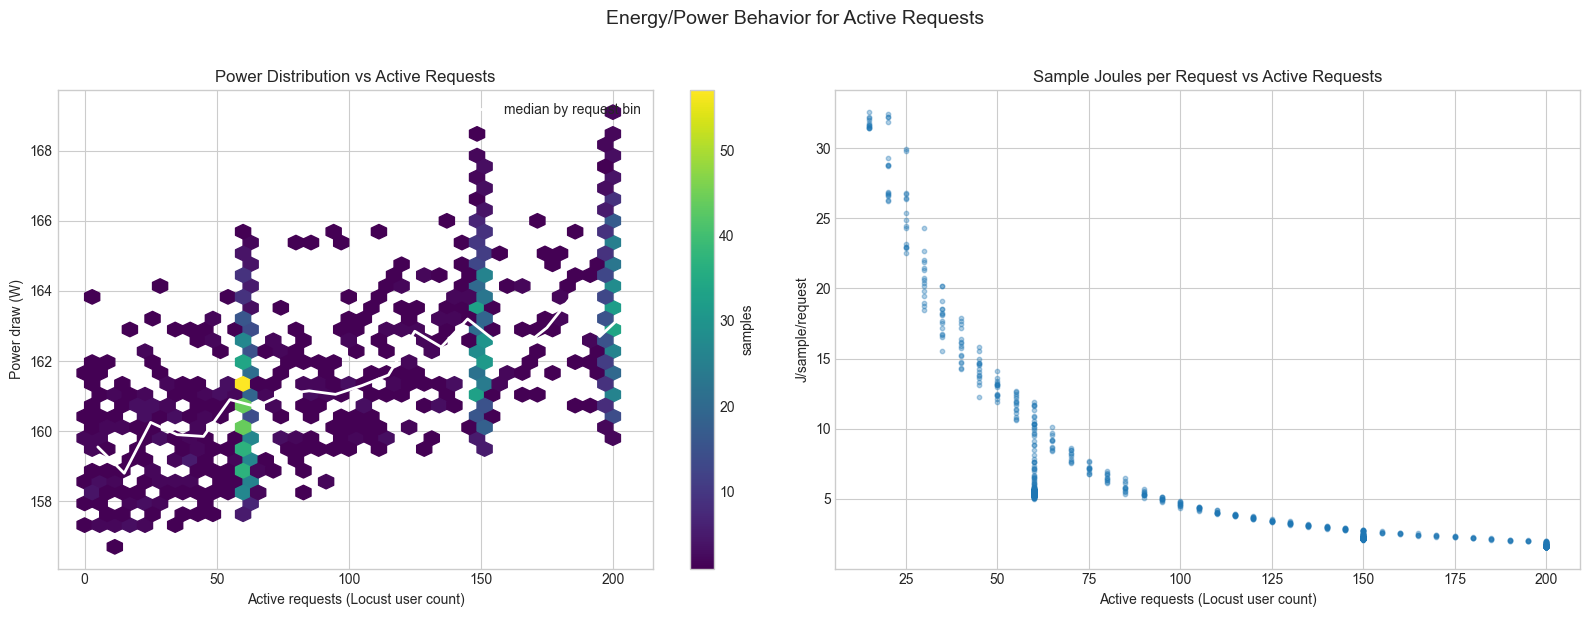

In [28]:
if request_power.empty:
    raise RuntimeError('No aligned request-power data was built.')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Distribution/density of power for active requests.
hb = axes[0].hexbin(
    request_power['active_requests'],
    request_power['apower'],
    gridsize=35,
    cmap='viridis',
    mincnt=1,
)
cbar = fig.colorbar(hb, ax=axes[0])
cbar.set_label('samples')

axes[0].set_title('Power Distribution vs Active Requests')
axes[0].set_xlabel('Active requests (Locust user count)')
axes[0].set_ylabel('Power draw (W)')

# Add a median trend line by request-count bins for readability.
bin_step = 10
bins = np.arange(0, request_power['active_requests'].max() + bin_step + 1, bin_step)
tmp = request_power.copy()
tmp['req_bin'] = pd.cut(tmp['active_requests'], bins=bins, right=False)
trend = tmp.groupby('req_bin', observed=True)['apower'].median().reset_index()
if not trend.empty:
    trend['req_mid'] = trend['req_bin'].apply(lambda x: (x.left + x.right) / 2)
    axes[0].plot(trend['req_mid'], trend['apower'], color='white', linewidth=2.0, label='median by request bin')
    axes[0].legend(loc='best')

# Right: Joules/sample per request-rate sample (optional no-time normalization view).
valid = request_power[request_power['joules_per_request_sample'].notna()]
axes[1].scatter(
    valid['active_requests'],
    valid['joules_per_request_sample'],
    s=10,
    alpha=0.35,
    color='#1f77b4',
)
axes[1].set_title('Sample Joules per Request vs Active Requests')
axes[1].set_xlabel('Active requests (Locust user count)')
axes[1].set_ylabel('J/sample/request')

fig.suptitle('Energy/Power Behavior for Active Requests', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

In [29]:
if cpu_power.empty:
    raise RuntimeError('No aligned CPU-power data was built.')

# Create 10%-wide CPU bins: 0-10, 10-20, ... up to observed max.
cpu_max = float(np.nanmax(cpu_power['cpu_utilization']))
upper = int(np.ceil(cpu_max / 10.0) * 10)
upper = max(10, upper)
edges = np.arange(0, upper + 10, 10)
cpu_power['cpu_bin'] = pd.cut(cpu_power['cpu_utilization'], bins=edges, right=False, include_lowest=True)

summary = cpu_power.groupby('cpu_bin', observed=True).agg(
    samples=('apower', 'size'),
    power_mean_w=('apower', 'mean'),
    power_median_w=('apower', 'median'),
    power_p10_w=('apower', lambda s: np.percentile(s, 10)),
    power_p90_w=('apower', lambda s: np.percentile(s, 90)),
).reset_index()

summary['cpu_bin_label'] = summary['cpu_bin'].astype(str)
summary

,cpu_bin,samples,power_mean_w,power_median_w,power_p10_w,power_p90_w,cpu_bin_label
0,"[0, 10)",195,162.124615,161.8,159.7,164.9,"[0, 10)"


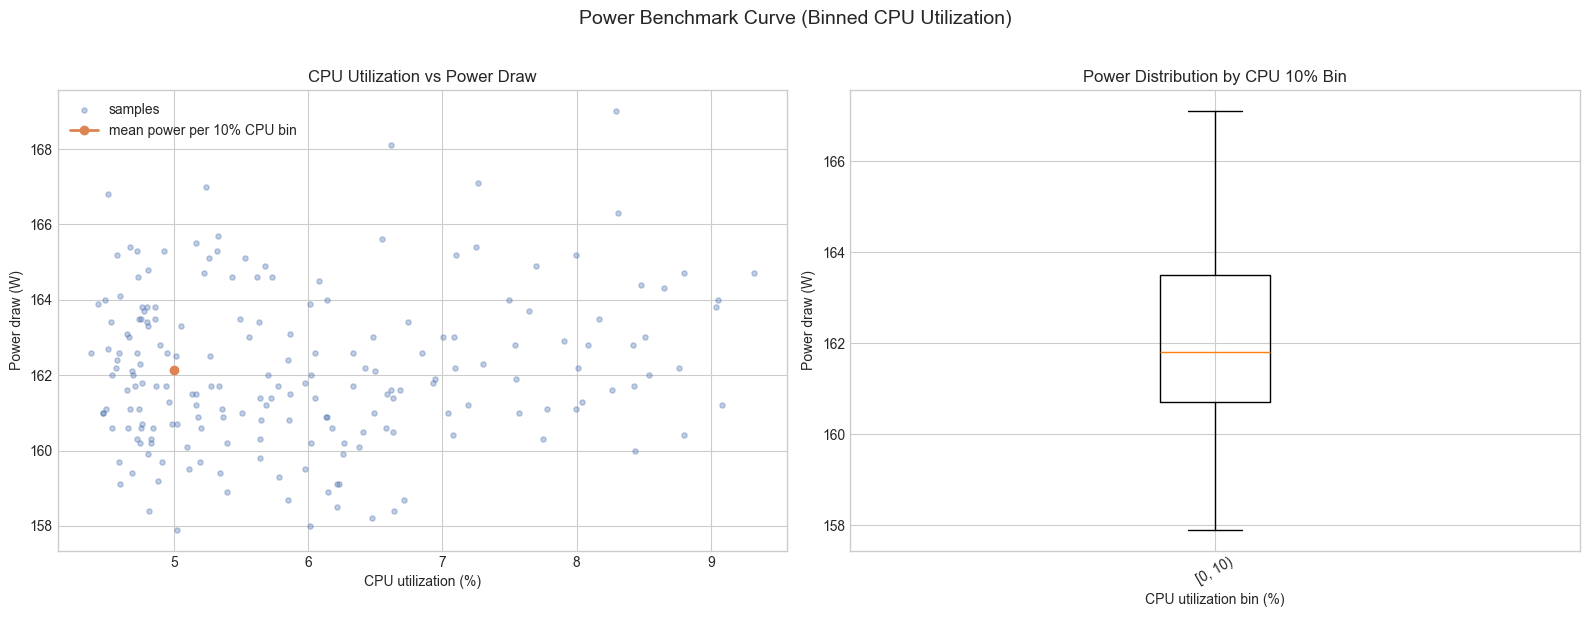

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw scatter + binned mean curve (benchmark trend).
axes[0].scatter(
    cpu_power['cpu_utilization'],
    cpu_power['apower'],
    s=14,
    alpha=0.35,
    color='#4c72b0',
    label='samples',
)

bin_mids = summary['cpu_bin'].apply(lambda x: (x.left + x.right) / 2)
axes[0].plot(
    bin_mids,
    summary['power_mean_w'],
    color='#dd8452',
    marker='o',
    linewidth=2,
    label='mean power per 10% CPU bin',
)
axes[0].set_title('CPU Utilization vs Power Draw')
axes[0].set_xlabel('CPU utilization (%)')
axes[0].set_ylabel('Power draw (W)')
axes[0].legend(loc='best')

# Right: distribution per 10% bin.
box_data = [cpu_power.loc[cpu_power['cpu_bin'] == b, 'apower'].values for b in summary['cpu_bin']]
axes[1].boxplot(box_data, tick_labels=summary['cpu_bin_label'], showfliers=False)
axes[1].set_title('Power Distribution by CPU 10% Bin')
axes[1].set_xlabel('CPU utilization bin (%)')
axes[1].set_ylabel('Power draw (W)')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Power Benchmark Curve (Binned CPU Utilization)', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()